# Silicon phonons with ASE and QEpy

Finite-displacement phonons using **`ase.phonons.Phonons`** and **`QEpyCalculator`** (Quantum ESPRESSO 7.2). Run from top to bottom; keep the pseudopotential in `pseudo_dir`.

In [ ]:
# Optional: pip install qepy ase matplotlib
 !pip install 'f90wrap==0.2.16' 'qepy' 'ase' 'matplotlib'


In [1]:
import matplotlib.pyplot as plt
from ase.build import bulk
from ase.phonons import Phonons
from qepy.calculator import QEpyCalculator


In [2]:
!wget https://pseudopotentials.quantum-espresso.org/upf_files/Si.pbe-n-kjpaw_psl.1.0.0.UPF

zsh:1: command not found: wget


## QE input (`qe_options`)

`QEpyCalculator` merges this with the current `Atoms` when writing the input (cell, `nat`, positions). `nosym` / `noinv` help finite displacements; tighten `conv_thr` for forces if needed.

In [3]:
qe_options = {
    '&control': {
        'calculation': "'scf'",
        'prefix': "'si_ph'",
        'pseudo_dir': "'./'",
        'outdir': "'./tmp_si_phonon_qepy'",
        'restart_mode': "'from_scratch'",
        'tprnfor': True,
    },
    '&system': {
        'ibrav': 0,
        'ecutwfc': 20,
        'ecutrho': 200,
        'nosym': True,
        'noinv': True,
    },
    '&electrons': {
        'conv_thr': 1.0e-10,
    },
    'atomic_species': ['Si 28.0855 Si.pbe-n-kjpaw_psl.1.0.0.UPF'],
    'k_points automatic': ['2 2 2 0 0 0'],
}


## Structure

Primitive silicon (diamond).

In [4]:
atoms = bulk('Si', 'diamond', a=5.43)


## Phonons (`run` → `read`)

`Phonons` builds supercells, runs SCF for each displacement, caches forces, then `read()` builds force constants. `ph.clean()` clears the cache folder for a reproducible rerun.

In [9]:
atoms.calc = QEpyCalculator(
    qe_options=qe_options,
    logfile='si_phonon_qepy.out',
    extrapolation=False,
)

supercell = (2, 2, 2)
ph = Phonons(atoms, atoms.calc, supercell=supercell, delta=0.05, name='phonon_si')

#ph.clean()
ph.run()
ph.read(method='frederiksen', acoustic=True)


## Phonon dispersion

Plot along a path in the Brillouin zone (ASE phonon energy units; see `Phonons` docs).

WARNING, 1 imaginary frequencies at q = ( 0.00,  0.00,  0.00) ; (omega_q = 2.066e-03*i)
WARNING, 1 imaginary frequencies at q = ( 0.06,  0.00,  0.06) ; (omega_q = 8.367e-02*i)
WARNING, 1 imaginary frequencies at q = ( 0.07,  0.07,  0.15) ; (omega_q = 4.866e-02*i)
WARNING, 2 imaginary frequencies at q = ( 0.04,  0.04,  0.07) ; (omega_q = 8.036e-02*i)
WARNING, 1 imaginary frequencies at q = ( 0.00,  0.00,  0.00) ; (omega_q = 2.066e-03*i)
WARNING, 1 imaginary frequencies at q = ( 0.06,  0.06,  0.06) ; (omega_q = 8.882e-02*i)
WARNING, 1 imaginary frequencies at q = ( 0.12,  0.12,  0.12) ; (omega_q = 2.696e-02*i)
WARNING, 1 imaginary frequencies at q = ( 0.31,  0.31,  0.31) ; (omega_q = 7.306e-02*i)


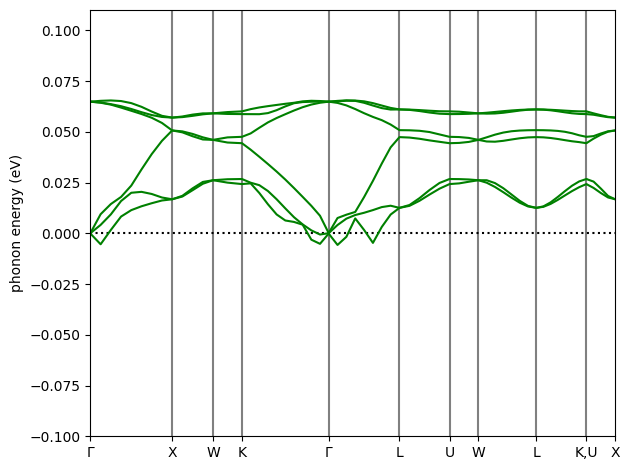

In [7]:
path_ph = atoms.cell.bandpath('GXWKGLUWLK,UX', npoints=60)
bs_ph = ph.get_band_structure(path_ph)
#print(bs_ph.energies[0])
ax = bs_ph.plot()
ax.set_ylabel('phonon energy (eV)')
plt.ylim(-0.1, 0.11)
plt.tight_layout()
plt.show()
